In [2]:
import pandas as pd

df_fake = pd.read_csv("/content/Fake.csv")
df_true = pd.read_csv("/content/True.csv")

df_fake["label"] = 0   # labelling the dataset so the computer can differenciate
df_true ["label"] = 1

#we are combining and mixing up both the datasets here
df = pd.concat([df_fake, df_true], axis=0)
df = df.sample(frac=1).reset_index(drop=True)
df.head(5)

,title,text,subject,date,label
0,REPUBLICANS WILL NEVER WATCH Arrogant JIMMY KI...,"Apparently, Kimmel s okay with throwing half o...",left-news,"Oct 15, 2017",0
1,"Trump STRANDED, In Full Panic As ANOTHER Perf...",President-elect Donald Trump has had trouble f...,News,"January 16, 2017",0
2,HOW OBAMA Is Putting Terrorist Boots On The Gr...,Every American should be demanding answers abo...,Government News,"Dec 19, 2015",0
3,Atzmon: Who Keeps Americans in the Dark?,". By Gilad AtzmonEarlier this week, senior Tab...",Middle-east,"August 18, 2017",0
4,Obama commutes prison terms of 42 non-violent ...,WASHINGTON (Reuters) - President Barack Obama ...,politicsNews,"June 3, 2016",1


In [4]:
df.info()
df.isnull().sum() #to check how many null values are there in each feature


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


,0
title,0
text,0
subject,0
date,0
label,0


No missing values so no need for futher modifications

In [5]:
df["content"] = df["title"] + " " + df["text"] #cobining the texts into one input for simplifications


EDA

<Axes: xlabel='label', ylabel='count'>

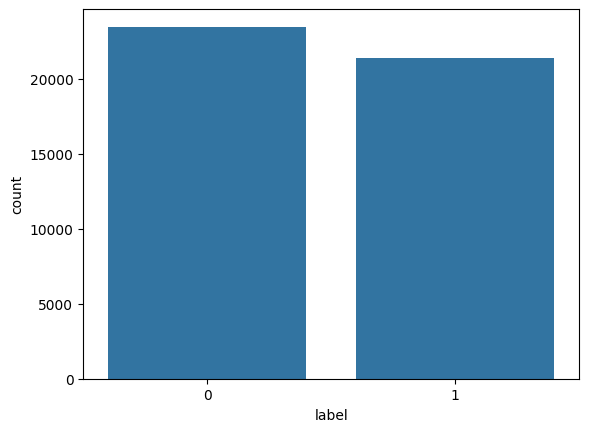

In [6]:
import seaborn as sns
sns.countplot(x="label", data=df) #to check if the dataset is balanced


<Axes: >

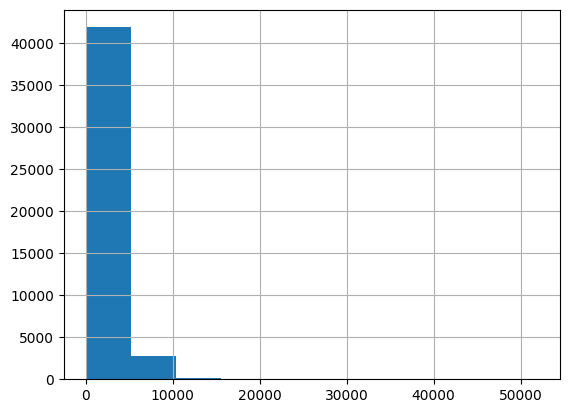

In [9]:
df["length"] = df["content"].apply(len)
df["length"].hist()


In [7]:
#checking the most common words that have appeared in the news(fake and real) to have a better insight

from collections import Counter
def get_top_words(label):
    text = " ".join(df[df["label"] == label]["content"])
    words = text.split()
    return Counter(words).most_common(20)

print("Fake News Words:\n", get_top_words(0))
print("\nReal News Words:\n", get_top_words(1))


Fake News Words:
 [('the', 484015), ('to', 287173), ('of', 234165), ('and', 213977), ('a', 203414), ('in', 153423), ('that', 138522), ('s', 127621), ('is', 105940), ('for', 88823), ('on', 77311), ('Trump', 70642), ('was', 66525), ('he', 62201), ('with', 60915), ('his', 55884), ('it', 54000), ('as', 51654), ('be', 47582), ('by', 45933)]

Real News Words:
 [('the', 423055), ('to', 251581), ('of', 207347), ('a', 187730), ('and', 180018), ('in', 173971), ('on', 108122), ('that', 82648), ('for', 80612), ('said', 72039), ('The', 55219), ('is', 54831), ('with', 54487), ('was', 47857), ('by', 47493), ('has', 46257), ('as', 46205), ('s', 44639), ('he', 43787), ('U.S.', 42143)]


Pre-processig the text:

In [8]:
#removing the punctuations and numbers from the text to make it clean

def clean_text(text):
    text = text.lower()
    text = ''.join([char if char.isalpha() else ' ' for char in text])
    return text
df["content"] = df["content"].apply(clean_text)

In [35]:
from sklearn.model_selection import train_test_split

X = df["content"]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


vectorizing the words for model training

In [36]:
#vectorizing the words for model training:

from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words="english")
X_train_tfidf = vec.fit_transform(X_train)
X_test_tfidf = vec.transform(X_test)


In [37]:
#model training :

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score
from sklearn.metrics import f1_score

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

In [23]:
#accuracy check:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.9876391982182628
F1 Score: 0.9871809677791893


In [38]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4702
           1       0.99      0.99      0.99      4278

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

[[4639   63]
 [  34 4244]]


We can see from the confusion matrix that , The model correctly classifies most news articles, with 4595 real news and 4274 fake news being identified accurately. Only a small number are misclassified (69 real as fake and 42 fake as real), which shows a high accuracy of the model on the given data

TESTING WITH NEAURAL NETWORK

In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt


In [12]:
X_train_nn = X_train_tfidf.toarray()
X_test_nn = X_test_tfidf.toarray()

nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(5000,)), #setting 128 neurons in the 1st hidden layer
    Dense(64, activation='relu'), #setting 64 neurons in the 2nd hidden layer
    Dense(1, activation='sigmoid') #setting 1 neurons in the final layer
])
nn_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

nn_model.summary()




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history= nn_model.fit(X_train_nn, y_train,epochs=5,batch_size=3,validation_split=0.2)
nn_model.evaluate(X_test_nn, y_test)

Epoch 1/5
9578/9578 ━━━━━━━━━━━━━━━━━━━━ 101s 10ms/step - accuracy: 0.9835 - loss: 0.0510 - val_accuracy: 0.9923 - val_loss: 0.0245
Epoch 2/5
9578/9578 ━━━━━━━━━━━━━━━━━━━━ 96s 10ms/step - accuracy: 0.9963 - loss: 0.0117 - val_accuracy: 0.9923 - val_loss: 0.0285
Epoch 3/5
9578/9578 ━━━━━━━━━━━━━━━━━━━━ 93s 10ms/step - accuracy: 0.9989 - loss: 0.0034 - val_accuracy: 0.9904 - val_loss: 0.0488
Epoch 4/5
9578/9578 ━━━━━━━━━━━━━━━━━━━━ 104s 11ms/step - accuracy: 0.9996 - loss: 0.0019 - val_accuracy: 0.9918 - val_loss: 0.0459
Epoch 5/5
9578/9578 ━━━━━━━━━━━━━━━━━━━━ 131s 10ms/step - accuracy: 0.9999 - loss: 2.9774e-04 - val_accuracy: 0.9928 - val_loss: 0.0611
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9920 - loss: 0.0663


[0.06634746491909027, 0.9919821619987488]

In [27]:
y_prob = nn_model.predict(X_test_nn, verbose=0).ravel()
y_pred1 = (y_prob >= 0.5).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy (sklearn):", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[4669   33]
 [  39 4239]]
Accuracy (sklearn): 0.9919821826280624


we can see from the confusion matrix that The model correctly classifies 4669 real news articles and 4239 fake news articles. It makes very few mistakes, with only 33 real news labeled as fakevand 39 fake news labeled as reals. This is a very strong model and works better than the logistic regression model

PLOTTING FOR BETTER VISUALIZATION OF THE MODEL LEARNING

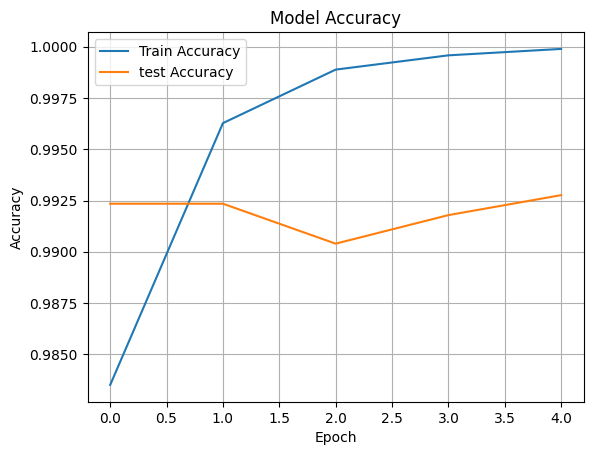

In [28]:
#plott of the model accuracy compared with the training set and the testng set

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

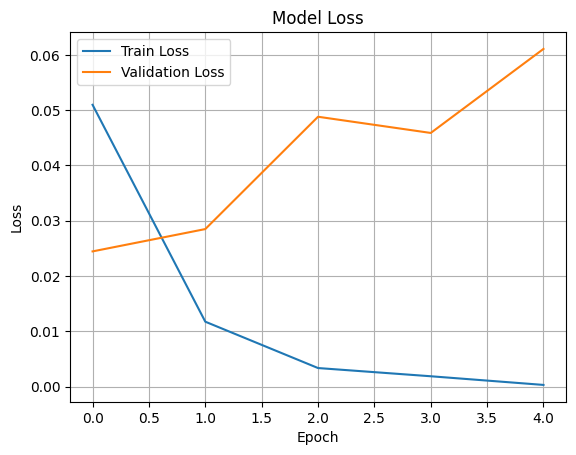

In [29]:
#plott of the loss, compared with the training set and the testng set

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

COMAPRING BETWEEN THE TWO MODELS(LOGISTIC REGRESSSION AND NN)


In [40]:
from sklearn.metrics import classification_report

print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred))

print("\nNeural Network Report:\n")
print(classification_report(y_test, y_pred1))


Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4702
           1       0.99      0.99      0.99      4278

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Neural Network Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4702
           1       0.99      0.99      0.99      4278

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



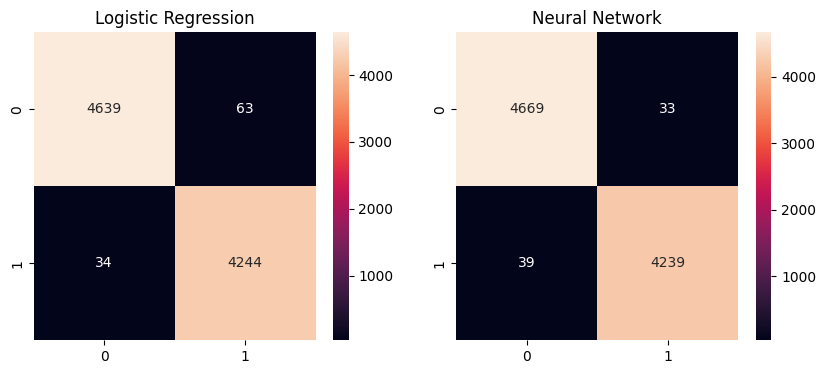

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm_lr = confusion_matrix(y_test, y_pred)
cm_nn = confusion_matrix(y_test, y_pred1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression")

plt.subplot(1,2,2)
sns.heatmap(cm_nn, annot=True, fmt='d')
plt.title("Neural Network")
plt.show()


So we can clearly see that the neural network model works better than the logistic regression model